In [1]:
import pandas as pd
import numpy as np


filepath = r"C:\Users\lucas\repositorios\mestrado_luedsbr\SRC\SOLVER\DB\getters\intermittent-renewables-production-france.csv"

# Carregar dados brutos
print(f"Carregando: {filepath}")
df = pd.read_csv(filepath)

# Processar data/hora
df['DateTime'] = pd.to_datetime(df['Date and Hour'].str.slice(stop=-6))
df = df.sort_values('DateTime')

# Separar vento e solar
df_wind = df[df['Source'] == 'Wind'].copy()
# Normalizar produção (fator 0-1)
for df_source in [df_wind]:
    if len(df_source) > 0:
        max_prod = df_source['Production'].max()
        if max_prod > 0:
            df_source['Factor'] = df_source['Production'] / max_prod
        else:
            df_source['Factor'] = 0

# Selecionar colunas finais
cols = ['DateTime', 'Production', 'Factor']
df_wind = df_wind[cols].copy()


# Renomear
df_wind.columns = ['timestamp', 'wind_production_mw', 'wind_factor']

print(f"✓ Vento: {len(df_wind)} registros")

Carregando: C:\Users\lucas\repositorios\mestrado_luedsbr\SRC\SOLVER\DB\getters\intermittent-renewables-production-france.csv
✓ Vento: 29904 registros


In [4]:
df_wind.head()

,timestamp,wind_production_mw,wind_factor
172,2020-01-01 00:00:00,3549.0,0.206098
11231,2020-01-01 01:00:00,2952.0,0.171429
9597,2020-01-01 02:00:00,2722.0,0.158072
175,2020-01-01 03:00:00,2753.0,0.159872
116,2020-01-01 04:00:00,2707.0,0.157201


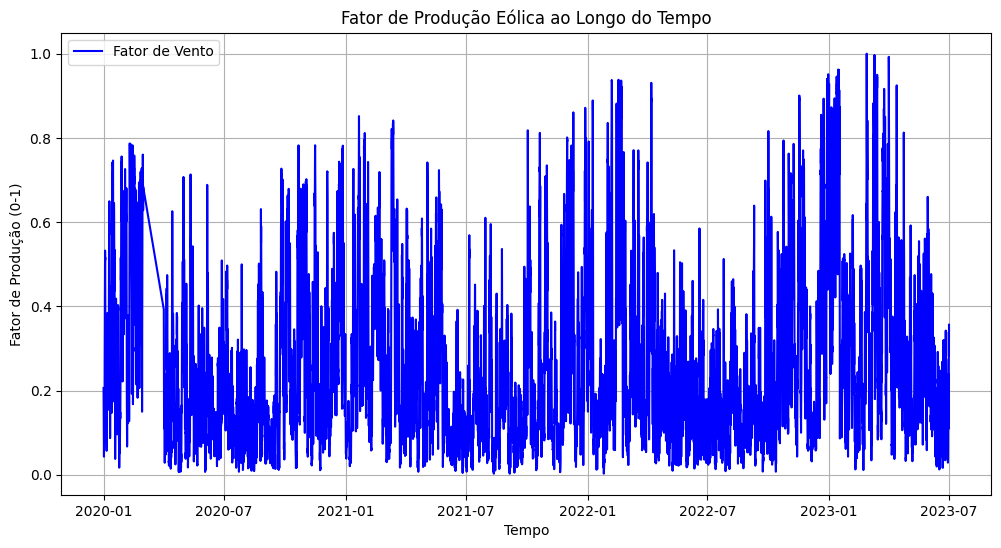

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(df_wind['timestamp'], df_wind['wind_factor'], label='Fator de Vento', color='blue')
plt.title('Fator de Produção Eólica ao Longo do Tempo') 
plt.xlabel('Tempo')
plt.ylabel('Fator de Produção (0-1)')
plt.legend()
plt.grid()
plt.show()

In [8]:
float(df_wind["wind_factor"].sample(1))

C:\Users\lucas\AppData\Local\Temp\ipykernel_44644\1728679354.py:1: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  float(df_wind["wind_factor"].sample(1))


0.444541231126597